In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/raw/structured_endometriosis_data.csv")

# Display first rows
df.head()

,Age,Menstrual_Irregularity,Chronic_Pain_Level,Hormone_Level_Abnormality,Infertility,BMI,Diagnosis
0,24,1,8.361531,0,0,19.451314,0
1,37,1,4.995508,0,0,22.388436,0
2,46,1,3.363996,1,0,21.320443,0
3,32,1,5.246037,0,0,20.177715,1
4,28,1,3.898932,1,0,23.538103,1


In [2]:
print("Rows, Columns:")
print(df.shape)

Rows, Columns:
(10000, 7)


In [3]:
print(df.columns.tolist())

['Age', 'Menstrual_Irregularity', 'Chronic_Pain_Level', 'Hormone_Level_Abnormality', 'Infertility', 'BMI', 'Diagnosis']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        10000 non-null  int64  
 1   Menstrual_Irregularity     10000 non-null  int64  
 2   Chronic_Pain_Level         10000 non-null  float64
 3   Hormone_Level_Abnormality  10000 non-null  int64  
 4   Infertility                10000 non-null  int64  
 5   BMI                        10000 non-null  float64
 6   Diagnosis                  10000 non-null  int64  
dtypes: float64(2), int64(5)
memory usage: 547.0 KB


In [5]:
df.isnull().sum()

Age                          0
Menstrual_Irregularity       0
Chronic_Pain_Level           0
Hormone_Level_Abnormality    0
Infertility                  0
BMI                          0
Diagnosis                    0
dtype: int64

In [6]:
df.describe()

,Age,Menstrual_Irregularity,Chronic_Pain_Level,Hormone_Level_Abnormality,Infertility,BMI,Diagnosis
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,33.692300,0.697500,5.030619,0.591100,0.298300,23.052865,0.407900
std,9.205308,0.459364,1.983955,0.491655,0.457535,3.891615,0.491469
min,18.000000,0.000000,0.000000,0.000000,0.000000,15.000000,0.000000
25%,26.000000,0.000000,3.671697,0.000000,0.000000,20.329327,0.000000
50%,34.000000,1.000000,5.035825,1.000000,0.000000,23.036315,0.000000
75%,42.000000,1.000000,6.396854,1.000000,1.000000,25.712923,1.000000
max,49.000000,1.000000,10.000000,1.000000,1.000000,37.146127,1.000000


In [7]:
df["Diagnosis"].value_counts()

Diagnosis
0    5921
1    4079
Name: count, dtype: int64

In [8]:
df["Diagnosis"].value_counts(normalize=True) * 100

Diagnosis
0    59.21
1    40.79
Name: proportion, dtype: float64

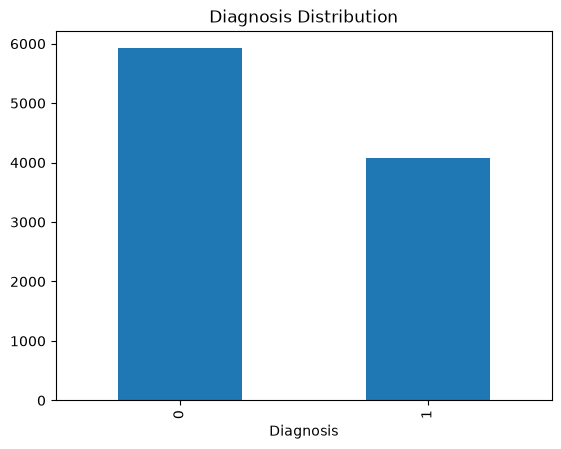

In [9]:
import matplotlib.pyplot as plt

df["Diagnosis"].value_counts().plot(kind="bar")

plt.title("Diagnosis Distribution")
plt.show()

In [18]:
import sys

print(sys.executable)

f:\Projects\endometriosis-ai\venv\Scripts\python.exe


In [19]:
import seaborn as sns

print(sns.__version__)

0.13.2


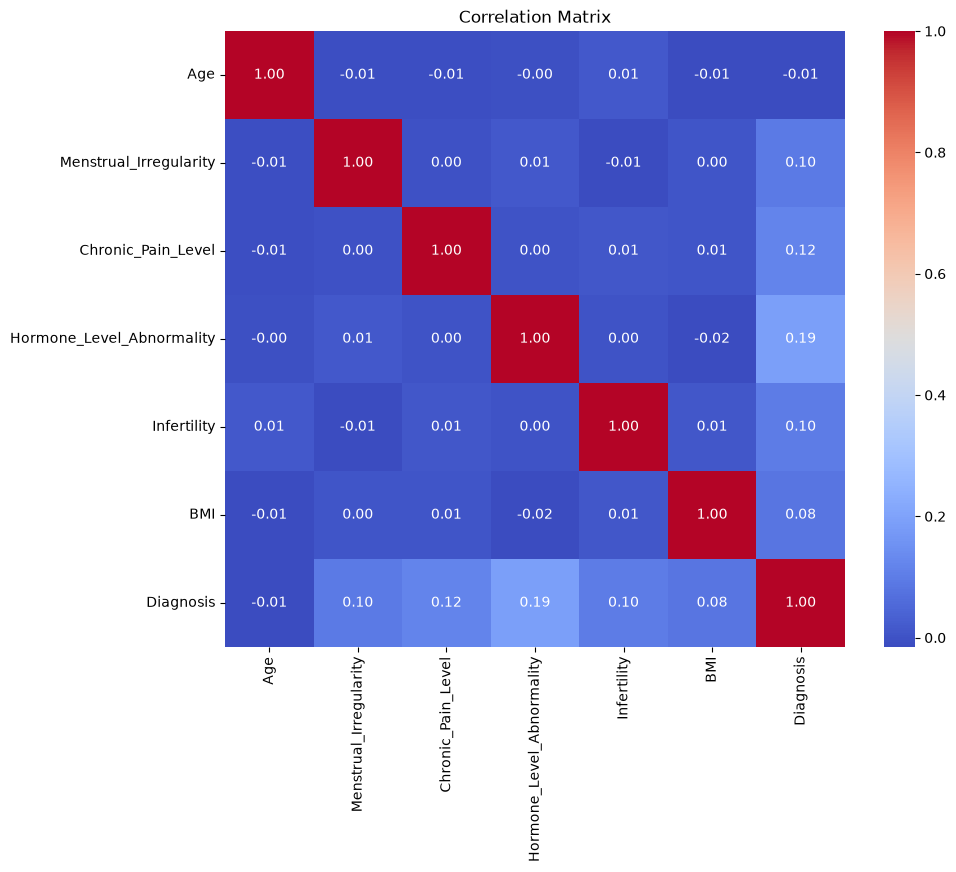

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

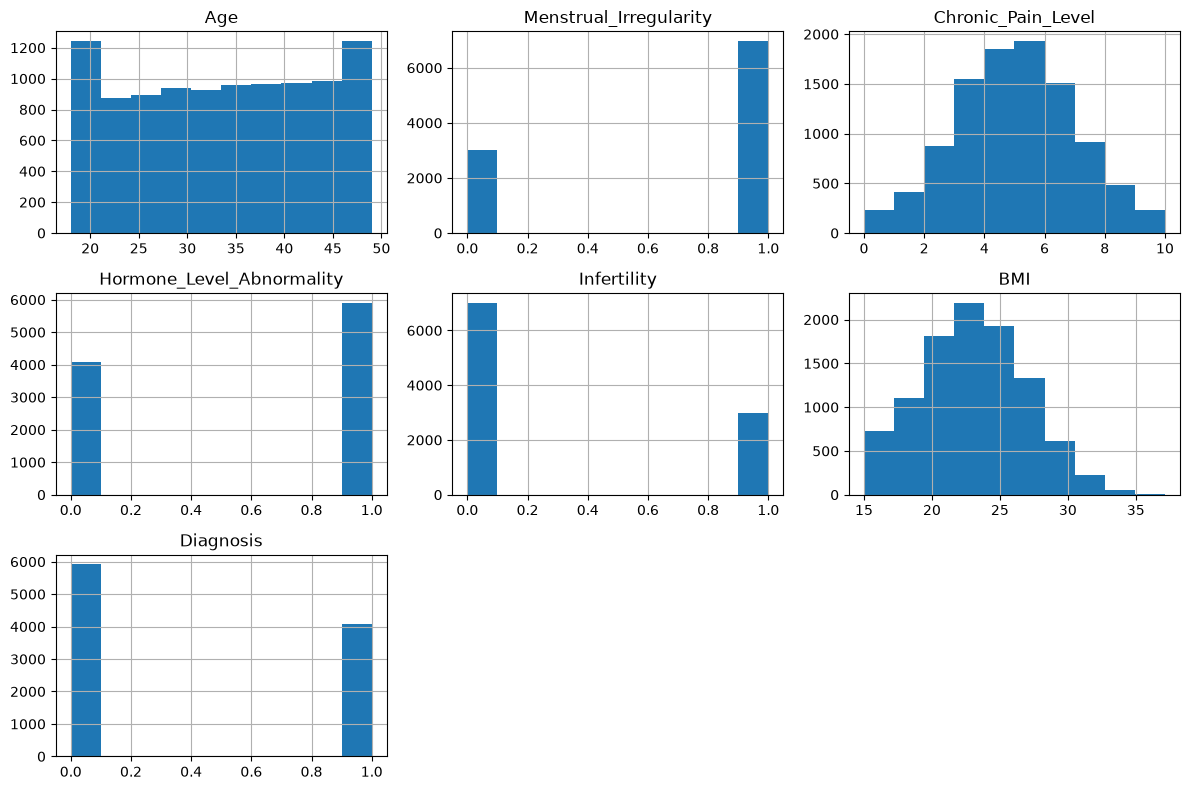

In [21]:
df.hist(figsize=(12,8))

plt.tight_layout()

plt.show()

In [22]:
pd.crosstab(
    df["Infertility"],
    df["Diagnosis"]
)

Diagnosis,0,1
Infertility,,
0,4371,2646
1,1550,1433


In [23]:
pd.crosstab(
    df["Menstrual_Irregularity"],
    df["Diagnosis"]
)

Diagnosis,0,1
Menstrual_Irregularity,,
0,2006,1019
1,3915,3060


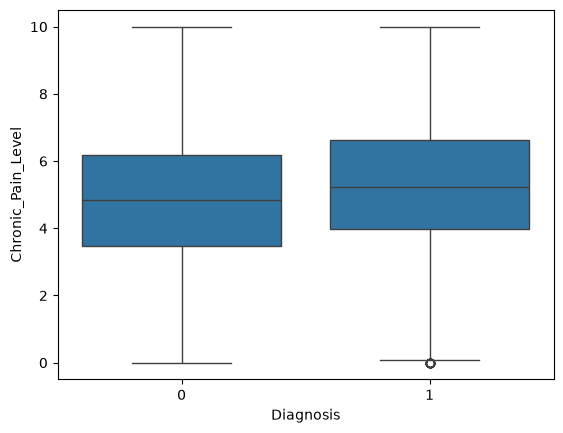

In [24]:
sns.boxplot(
    x="Diagnosis",
    y="Chronic_Pain_Level",
    data=df
)

plt.show()

# Logistic Regression Baseline

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Features
X = df.drop("Diagnosis", axis=1)

# Target
y = df["Diagnosis"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model
model = LogisticRegression(max_iter=1000)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Probability scores
y_prob = model.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nROC AUC:")
print(roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:
0.635

ROC AUC:
0.657335014712064

Confusion Matrix:
[[983 237]
 [493 287]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.81      0.73      1220
           1       0.55      0.37      0.44       780

    accuracy                           0.64      2000
   macro avg       0.61      0.59      0.58      2000
weighted avg       0.62      0.64      0.62      2000



# Random Forest Baseline

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

print("Accuracy:")
print(accuracy_score(y_test, rf_pred))

print("\nROC AUC:")
print(roc_auc_score(y_test, rf_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy:
0.598

ROC AUC:
0.6104728877679698

Confusion Matrix:
[[878 342]
 [462 318]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.72      0.69      1220
           1       0.48      0.41      0.44       780

    accuracy                           0.60      2000
   macro avg       0.57      0.56      0.56      2000
weighted avg       0.59      0.60      0.59      2000



In [27]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
2,Chronic_Pain_Level,0.367068
5,BMI,0.360054
0,Age,0.206690
3,Hormone_Level_Abnormality,0.035162
4,Infertility,0.015821
1,Menstrual_Irregularity,0.015206


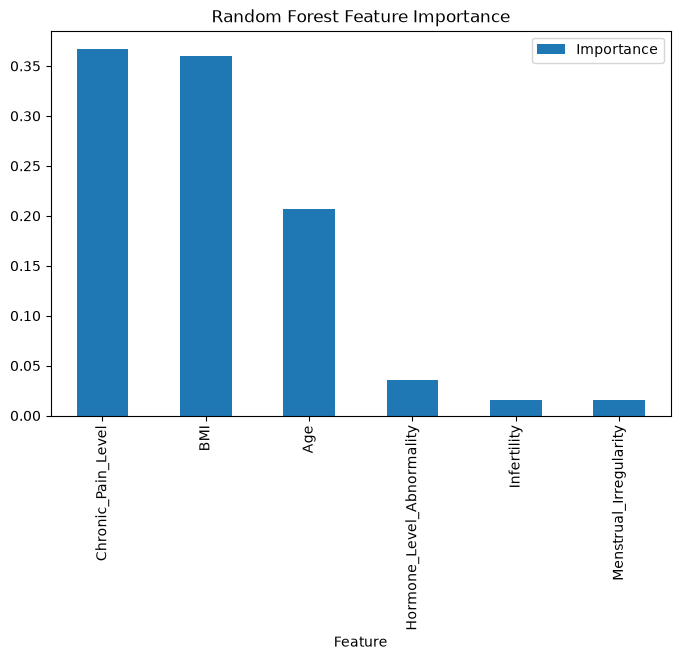

In [28]:
feature_importance.sort_values(
    by="Importance",
    ascending=False
).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(8,5)
)

plt.title("Random Forest Feature Importance")
plt.show()

In [29]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

print("Accuracy:")
print(accuracy_score(y_test, xgb_pred))

print("\nROC AUC:")
print(roc_auc_score(y_test, xgb_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Accuracy:
0.6305

ROC AUC:
0.6436165405632619

Confusion Matrix:
[[960 260]
 [479 301]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.79      0.72      1220
           1       0.54      0.39      0.45       780

    accuracy                           0.63      2000
   macro avg       0.60      0.59      0.59      2000
weighted avg       0.62      0.63      0.62      2000



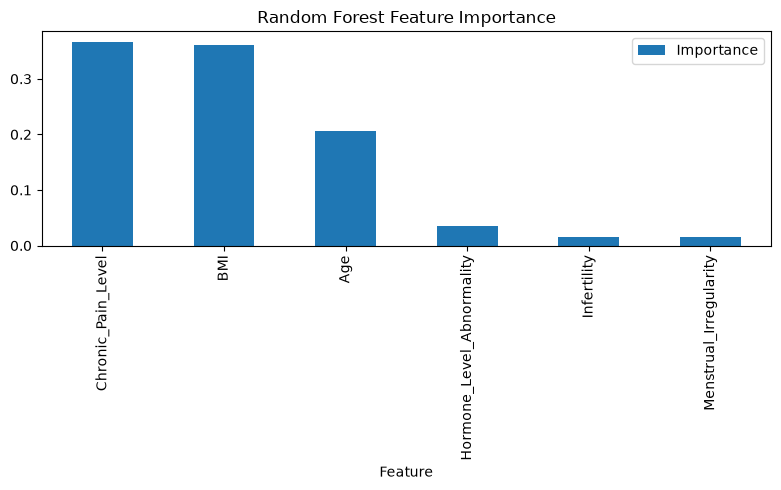

In [30]:
feature_importance.sort_values(
    by="Importance",
    ascending=False
).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(8,5)
)

plt.title("Random Forest Feature Importance")
plt.tight_layout()

plt.savefig(
    "../docs/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

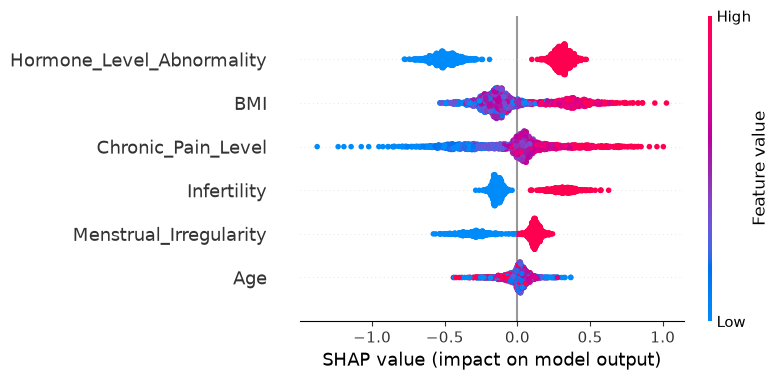

In [31]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

In [33]:
import joblib

joblib.dump(
    xgb,
    "../models/endometriosis_model.pkl"
)

['../models/endometriosis_model.pkl']